In [97]:
import pandas as pd

df = pd.read_csv('synthetic_donations.csv', parse_dates=['date'])

In [98]:
# 1) Agregasi per sender: total, count, mean, std
agg_sender = df.groupby('sender')['amount'].agg(
    total_donasi_sender='sum',
    jumlah_transaksi_sender='count',
    rata_rata_donasi_sender='mean',
    std_donasi_sender='std'
).reset_index()

# Gabungkan agregasi ke df original
df = pd.merge(df, agg_sender, on='sender', how='left')

# 2) Jumlah transaksi dalam 30 hari terakhir per sender menggunakan rolling window
df_temp = df.sort_values(['sender','date']).reset_index(drop=True)
df_temp = df_temp.set_index('date')
df_temp['jumlah_donasi_30hari_sender'] = (
    df_temp.groupby('sender')['amount']
           .transform(lambda x: x.rolling('30D').count())
)
df_temp = df_temp.reset_index()
df = pd.merge(df, df_temp[['sender','date','jumlah_donasi_30hari_sender']],
              on=['sender','date'], how='left')

# 3) Selisih waktu antar transaksi per sender
df_temp = df.sort_values(['sender','date']).copy()
df_temp['diff_days'] = df_temp.groupby('sender')['date'].diff().dt.days
avg_diff = df_temp.groupby('sender')['diff_days'].mean().reset_index().rename(
    columns={'diff_days':'selang_waktu_rata2_sender'}
)
df = pd.merge(df, avg_diff, on='sender', how='left')

In [99]:
# Jumlah penerima unik per sender (out-degree)
sender_to_receivers = df.groupby('sender')['receiver'].nunique().reset_index().rename(
    columns={'receiver':'receiver_unik_per_sender'}
)
df = pd.merge(df, sender_to_receivers, on='sender', how='left')
# Degree centrality (out-degree) sama dengan jumlah penerima unik
df['degree_centrality_sender'] = df['receiver_unik_per_sender']

# Jumlah donor unik per receiver (in-degree)
receiver_from_senders = df.groupby('receiver')['sender'].nunique().reset_index().rename(
    columns={'sender':'sender_unik_per_receiver'}
)
df = pd.merge(df, receiver_from_senders, on='receiver', how='left')
# Degree centrality (in-degree) sama dengan jumlah donor unik
df['degree_centrality_receiver'] = df['sender_unik_per_receiver']

In [100]:
# Total donasi per sender (sudah dihitung sebelumnya sebagai total_donasi_sender)
# Hitung total per pasangan (sender, receiver)
sum_per_sr = df.groupby(['sender','receiver'])['amount'].sum().reset_index()
# Cari nilai maksimum per sender
max_donasi = sum_per_sr.groupby('sender')['amount'].max().reset_index().rename(
    columns={'amount':'max_donasi_satu_receiver'}
)
# Gabungkan dan hitung proporsi
df = pd.merge(df, max_donasi, on='sender', how='left')
df['proporsi_donasi_terbesar_per_sender'] = (
    df['max_donasi_satu_receiver'] / df['total_donasi_sender']
)

In [101]:
# Tentukan batas masing-masing tipe
def exceeds_limit(row):
    s, r, amt = row['sender_type'], row['receiver_type'], row['amount']
    if s=='individual' and r=='political-party' and amt > 200_000_000:
        return True
    if s=='corporation' and r=='political-party' and amt > 800_000_000:
        return True
    if s=='individual' and r=='individual' and amt > 2_500_000_000:
        return True
    if s=='corporation' and r=='individual' and amt > 25_000_000_000:
        return True
    return False

df['flag_donasi_melebihi_batas'] = df.apply(exceeds_limit, axis=1)

In [102]:
df.to_csv('featured_synthetic_donations.csv', index=False)

In [103]:
drop_cols = ['sender','receiver','date','risk_type',
             'std_donasi_sender','selang_waktu_rata2_sender','flag_donasi_melebihi_batas']
X = df.drop(columns=drop_cols + ['risk'])
y = df['risk'].astype(int)

In [104]:
from sklearn.preprocessing import LabelEncoder
le_sender = LabelEncoder()
le_receiver = LabelEncoder()
X['sender_type_enc'] = le_sender.fit_transform(df['sender_type'])
X['receiver_type_enc'] = le_receiver.fit_transform(df['receiver_type'])
X = X.drop(columns=['sender_type','receiver_type'])

In [105]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42, stratify=y)
print("Jumlah latih:", len(X_train), "Jumlah uji:", len(X_test))
print("Distribusi label latih:\n", y_train.value_counts(),
      "\nDistribusi label uji:\n", y_test.value_counts())

Jumlah latih: 6701 Jumlah uji: 3301
Distribusi label latih:
 risk
1    3351
0    3350
Name: count, dtype: int64 
Distribusi label uji:
 risk
1    1651
0    1650
Name: count, dtype: int64


In [106]:
# import lightgbm as lgb
# model = lgb.LGBMClassifier(random_state=42)
# model.fit(X_train, y_train)

In [107]:
import lightgbm as lgb
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()  # kalau data tidak seimbang
model = lgb.LGBMClassifier(
    random_state=42,
    n_estimators=800,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=2.0,
    scale_pos_weight=pos_weight  # penting saat imbalance
)
model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 3351, number of negative: 3350
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001166 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1358
[LightGBM] [Info] Number of data points in the train set: 6701, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500075 -> initscore=0.000298
[LightGBM] [Info] Start training from score 0.000298
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, n_estimators=800,
               num_leaves=63, random_state=42, reg_alpha=1.0, reg_lambda=2.0,
               scale_pos_weight=np.float64(0.9997015816174276), subsample=0.8)

In [108]:
# import lightgbm as lgb
# from sklearn.model_selection import StratifiedKFold
# from sklearn.metrics import average_precision_score

# X_train_, X_valid_, y_train_, y_valid_ = X_train, X_test, y_train, y_test  # ganti sesuai split Anda

# best_ap, best_cfg = -1, None
# for spw in [0.5, 1.0, 1.5, 2.0, 3.0]:
#     model = lgb.LGBMClassifier(
#         random_state=42, n_estimators=800, learning_rate=0.05,
#         num_leaves=63, subsample=0.8, colsample_bytree=0.8,
#         reg_alpha=1.0, reg_lambda=2.0, scale_pos_weight=spw
#     )
#     model.fit(X_train_, y_train_)
#     ap = average_precision_score(y_valid_, model.predict_proba(X_valid_)[:,1])
#     print(f"spw={spw:<4}  AP={ap:.4f}")
#     if ap > best_ap:
#         best_ap, best_cfg = ap, spw

# print("Best scale_pos_weight:", best_cfg, "AP:", best_ap)

In [109]:
# y_pred = model.predict(X_test)
# y_proba = model.predict_proba(X_test)[:,1]

# from sklearn.calibration import CalibratedClassifierCV
# cal = CalibratedClassifierCV(model, method='isotonic', cv=3)
# cal.fit(X_train, y_train)
# y_proba_cal = cal.predict_proba(X_test)[:,1]

In [110]:
# from sklearn.metrics import classification_report, f1_score, confusion_matrix, roc_auc_score, roc_curve
# import numpy as np
# import matplotlib.pyplot as plt

# # === after: model.fit(X_train, y_train) ===
# # Predict class labels and probabilities
# y_pred  = model.predict(X_test)                    # shape (n_samples,)
# y_proba = model.predict_proba(X_test)[:, 1]        # positive-class probs

# # F1 scores
# print("F1 (binary avg):  ", f1_score(y_test, y_pred, average='binary'))
# print("F1 (macro avg):   ", f1_score(y_test, y_pred, average='macro'))
# print("F1 (weighted avg):", f1_score(y_test, y_pred, average='weighted'))

# # Full classification report
# print(classification_report(
#     y_test, y_pred,
#     target_names=['not_risky(0)', 'risky(1)'],
#     digits=4, zero_division=0
# ))

# # Confusion matrix
# cm = confusion_matrix(y_test, y_pred)
# print("Confusion matrix:\n", cm)

# # ROC-AUC & ROC curve
# auc = roc_auc_score(y_test, y_proba)
# print(f"ROC-AUC: {auc:.4f}")

# fpr, tpr, th = roc_curve(y_test, y_proba)
# plt.figure()
# plt.plot(fpr, tpr, label=f'ROC (AUC={auc:.3f})')
# plt.plot([0,1],[0,1],'--')
# plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curve'); plt.legend(); plt.show()

Chosen threshold: 0.3865
Recall risky (TPR):      0.775
Recall not_risky (TNR):  0.700
F1 (binary): 0.7472270869819031
              precision    recall  f1-score   support

not_risky(0)     0.7569    0.7000    0.7273      1650
    risky(1)     0.7211    0.7753    0.7472      1651

    accuracy                         0.7377      3301
   macro avg     0.7390    0.7376    0.7373      3301
weighted avg     0.7390    0.7377    0.7373      3301

Confusion matrix:
 [[1155  495]
 [ 371 1280]]
ROC-AUC: 0.8424


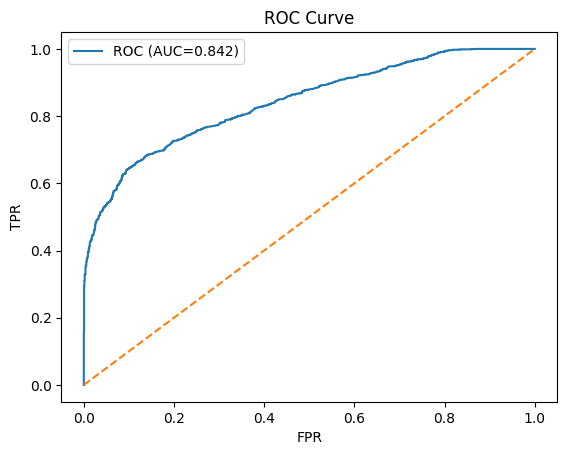

In [111]:
import numpy as np
from sklearn.metrics import classification_report, f1_score, confusion_matrix, roc_auc_score, roc_curve

# y_test: {0,1} with 1=risky
y_proba = model.predict_proba(X_test)[:, 1]

# ROC curve gives FPR, TPR and thresholds
fpr, tpr, thr = roc_curve(y_test, y_proba)
recall_not_risky = 1 - fpr  # specificity

# keep thresholds that satisfy the constraint: recall_not_risky >= 0.70
mask = recall_not_risky >= 0.70
if np.any(mask):
    # among feasible points, maximize recall for risky (TPR)
    i = np.argmax(tpr[mask])
    thr_use = thr[mask][i]
else:
    # no threshold meets the constraint; pick the closest one
    i = np.argmin(np.abs(recall_not_risky - 0.70))
    thr_use = thr[i]
    print("[warn] No threshold meets recall_not_risky >= 0.70 exactly; using closest.")

# Apply the chosen threshold
y_pred_adj = (y_proba >= thr_use).astype(int)

# Report metrics
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_adj).ravel()
recall_risky      = tp / (tp + fn) if (tp + fn) else 0.0
recall_not_risky2 = tn / (tn + fp) if (tn + fp) else 0.0

print(f"Chosen threshold: {thr_use:.4f}")
print(f"Recall risky (TPR):      {recall_risky:.3f}")
print(f"Recall not_risky (TNR):  {recall_not_risky2:.3f}")
print("F1 (binary):", f1_score(y_test, y_pred_adj, average='binary'))
print(classification_report(y_test, y_pred_adj, target_names=['not_risky(0)','risky(1)'], digits=4))
print("Confusion matrix:\n", np.array([[tn, fp],[fn, tp]]))

# ROC-AUC & ROC curve
auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {auc:.4f}")

fpr, tpr, th = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curve'); plt.legend(); plt.show()

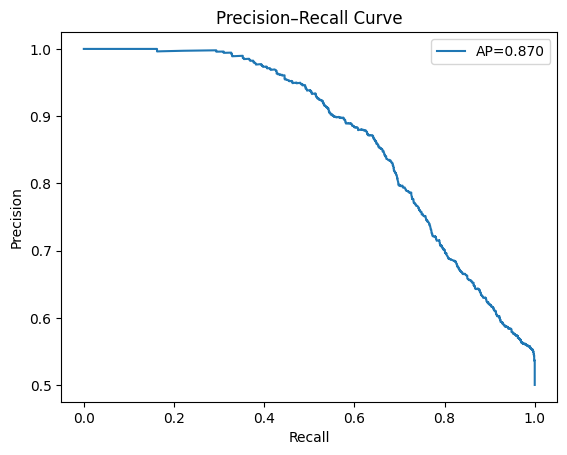

In [112]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

prec, rec, thr = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
plt.plot(rec, prec, label=f'AP={ap:.3f}')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Precision–Recall Curve'); plt.legend(); plt.show()


In [113]:
# import numpy as np
# from sklearn.metrics import confusion_matrix, classification_report, f1_score

# def pick_threshold_with_constraint(y_true, y_proba, min_recall_not_risky=0.70, beta=None):
#     """
#     If beta is None: maximize recall for risky (class 1).
#     If beta is set (e.g., 2.0): maximize Fβ for risky under the constraint.
#     """
#     thresholds = np.unique(np.concatenate([y_proba, [0.0, 1.0]]))
#     best = None

#     for thr in thresholds:
#         y_pred = (y_proba >= thr).astype(int)
#         tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
#         rec_pos = tp / (tp + fn) if (tp + fn) else 0.0      # recall risky
#         rec_neg = tn / (tn + fp) if (tn + fp) else 0.0      # recall not_risky (specificity)

#         if rec_neg >= min_recall_not_risky:
#             if beta is None:
#                 score = rec_pos
#             else:
#                 prec = tp / (tp + fp) if (tp + fp) else 0.0
#                 score = (1+beta**2) * (prec*rec_pos) / (beta**2*prec + rec_pos + 1e-12)
#             if (best is None) or (score > best[0]):
#                 best = (score, thr, rec_pos, rec_neg, prec if 'prec' in locals() else None)

#     # If nothing meets the constraint, return the closest specificity to the target
#     if best is None:
#         diffs = []
#         for thr in thresholds:
#             y_pred = (y_proba >= thr).astype(int)
#             tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
#             rec_neg = tn / (tn + fp) if (tn + fp) else 0.0
#             diffs.append((abs(rec_neg - min_recall_not_risky), thr))
#         diffs.sort()
#         thr = diffs[0][1]
#         y_pred = (y_proba >= thr).astype(int)
#         tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
#         rec_pos = tp / (tp + fn) if (tp + fn) else 0.0
#         rec_neg = tn / (tn + fp) if (tn + fp) else 0.0
#         return thr, rec_pos, rec_neg, True

#     _, thr, rec_pos, rec_neg, _ = best
#     return thr, rec_pos, rec_neg, False

# # --- usage ---
# y_proba = model.predict_proba(X_test)[:, 1]

# # Maximize risky recall under recall(not_risky) >= 0.70
# thr_use, rec_pos, rec_neg, relaxed = pick_threshold_with_constraint(
#     y_test, y_proba, min_recall_not_risky=0.70, beta=None
# )
# y_pred_adj = (y_proba >= thr_use).astype(int)

# print(f"Chosen threshold: {thr_use:.4f} | recall_risky={rec_pos:.3f} | recall_not_risky={rec_neg:.3f}"
#       + (" [closest-to-constraint]" if relaxed else ""))

# print("F1(binary):", f1_score(y_test, y_pred_adj))
# print(classification_report(y_test, y_pred_adj, target_names=['not_risky(0)','risky(1)'], digits=4))
# print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_adj))


In [114]:
import pandas as pd
imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)
print(imp)

                                feature  importance
0                                amount       11260
3               rata_rata_donasi_sender        9238
9              max_donasi_satu_receiver        9005
1                   total_donasi_sender        8643
7              sender_unik_per_receiver        4685
10  proporsi_donasi_terbesar_per_sender        4255
8            degree_centrality_receiver        1178
11                      sender_type_enc         840
5              receiver_unik_per_sender         254
2               jumlah_transaksi_sender         148
12                    receiver_type_enc          26
4           jumlah_donasi_30hari_sender           8
6              degree_centrality_sender           0
